In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [ ]:
import sys
from pathlib import Path

from src.image_utils import (
    compare_images,
    display_image,
    image_statistics,
    normalize_image,
    resize_image,
)

from src.phantom import (
    generate_circle,
    generate_multiple_circles,
    generate_rectangle,
    generate_shepp_logan,
)

The Modified Shepp–Logan phantom is a standard benchmark in MRI and CT reconstruction. It approximates anatomical structures using multiple ellipses with varying intensities and serves as the primary reference image throughout this investigation.

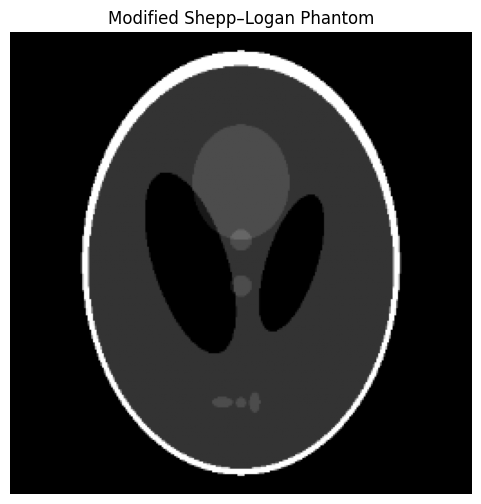

In [ ]:
#Generate the Modified Shepp–Logan Phantom
shepp = generate_shepp_logan()

display_image(
    shepp,
    title="Modified Shepp–Logan Phantom"
)

To complement the anatomical phantom, simple geometric phantoms are generated. These controlled structures facilitate analysis of spatial resolution, contrast, and reconstruction artifacts.

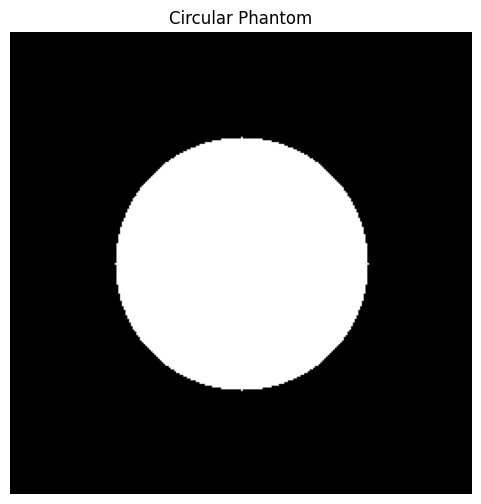

In [ ]:
circle = generate_circle()

display_image(
    circle,
    title="Circular Phantom"
)

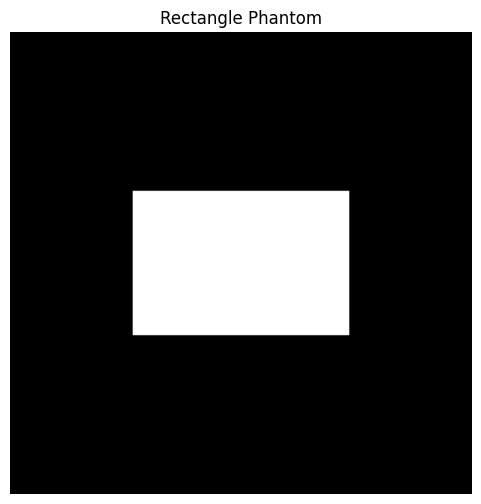

In [ ]:
rectangle = generate_rectangle()

display_image(
    rectangle,
    title="Rectangle Phantom"
)

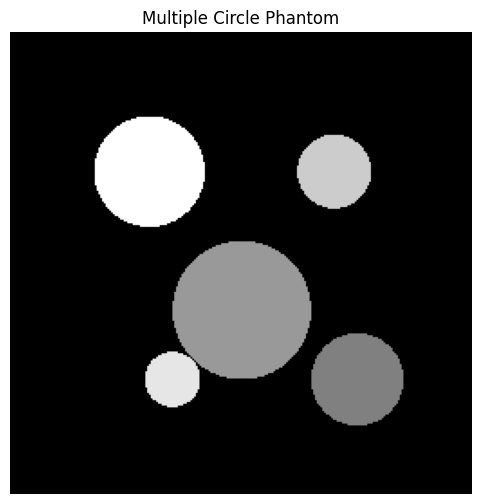

In [ ]:
multi = generate_multiple_circles()

display_image(
    multi,
    title="Multiple Circle Phantom"
)

Basic image statistics provide a quantitative summary of the generated phantom and establish a baseline for subsequent processing steps.

In [ ]:
stats = image_statistics(shepp)

for key, value in stats.items():
    print(f"{key}: {value}")

Shape: (256, 256)
Data Type: float32
Minimum: 0.0
Maximum: 1.0
Mean: 0.12305779755115509
Standard Deviation: 0.20892135798931122


Image normalization rescales intensities to a common range, ensuring consistent visualization and facilitating comparisons across experiments.

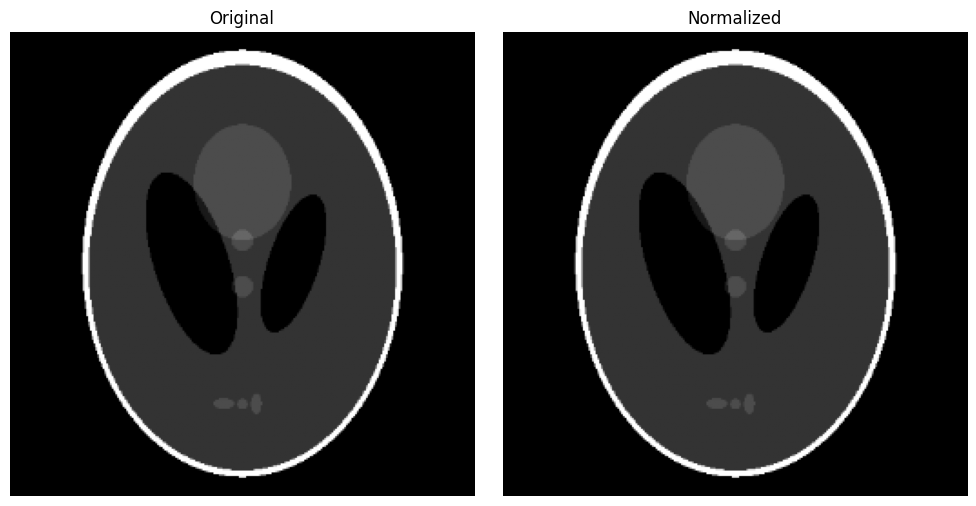

In [ ]:
normalized = normalize_image(shepp)

compare_images(
    shepp,
    normalized,
    "Original",
    "Normalized"
)

MRI datasets are reconstructed at different matrix sizes depending on acquisition parameters. This experiment illustrates the effect of changing image dimensions.

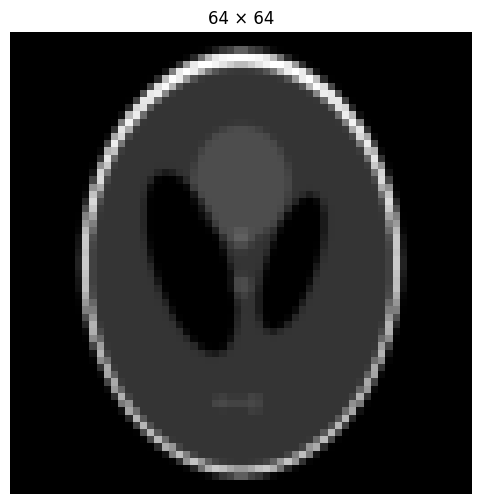

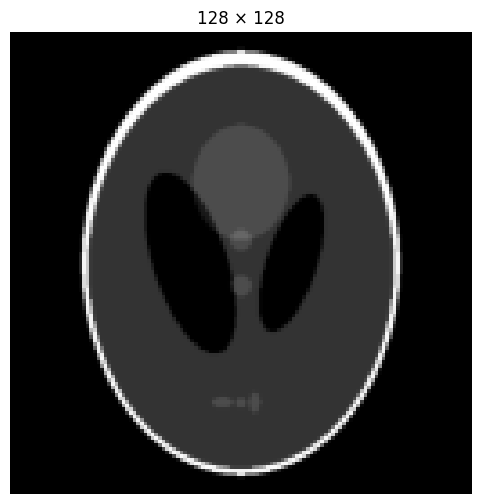

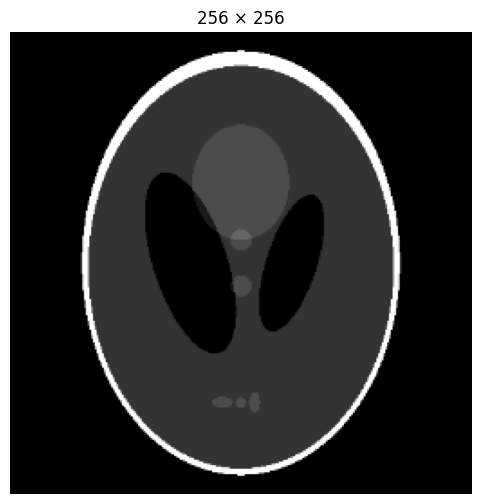

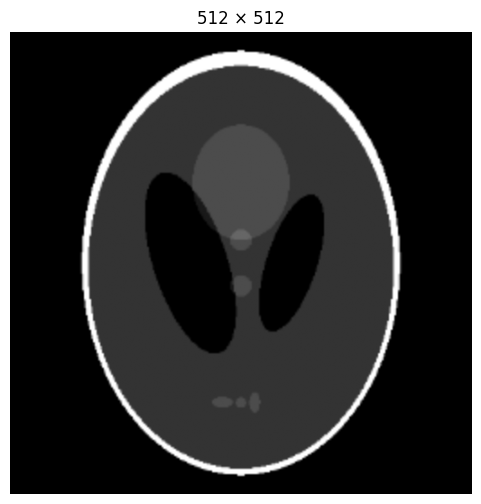

In [ ]:
sizes = [64, 128, 256, 512]

for s in sizes:

    resized = resize_image(shepp, s)

    display_image(
        resized,
        title=f"{s} × {s}"
    )

Comparing anatomical and geometric phantoms highlights their complementary roles in evaluating reconstruction algorithms.

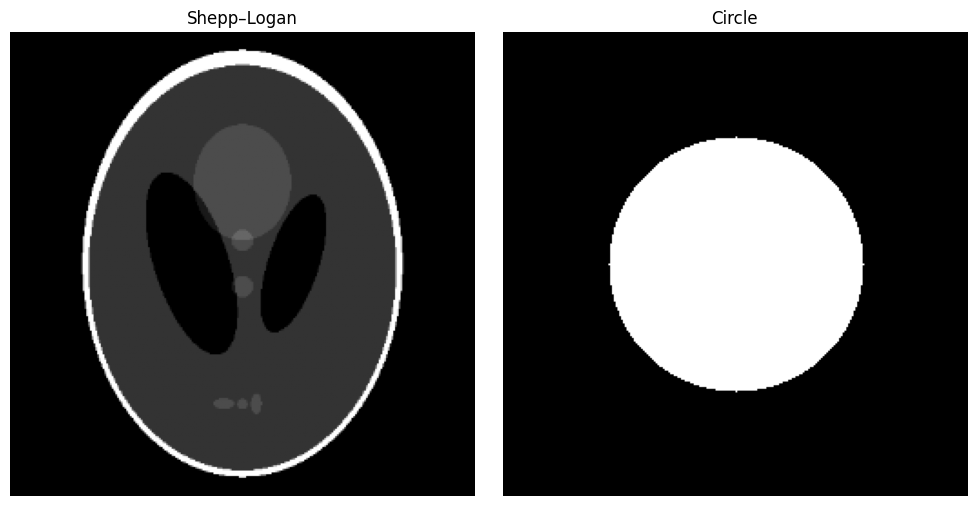

In [ ]:
#Comparison of Anatomical and Geometric Phantoms
compare_images(
    shepp,
    circle,
    "Shepp–Logan",
    "Circle"
)

## Discussion

In this notebook, we established the computational framework for the MRI reconstruction investigation by generating synthetic phantoms and implementing reusable image processing utilities. The Modified Shepp–Logan phantom provides a realistic anatomical reference, while the geometric phantoms enable controlled evaluation of reconstruction behavior. These datasets will serve as the ground truth for all subsequent experiments involving Fourier transformation, k-space sampling, undersampling, and image reconstruction.